In [102]:
import numpy as np
import random
import time
from flappy_bird import FlappyBirds
from tqdm import tqdm
import matplotlib.pyplot as plt

In [103]:
nx, ny = 10, 10
env = FlappyBirds(nx = nx, ny = ny, reward=[-1, 0, 1])

In [104]:
q_table = np.zeros((nx, ny, ny, len(env.action_space)))  # (nx, ny, ny, 2)

In [105]:
num_episodes = 20000

learning_rate = 0.1/num_episodes  # alpha
discount_rate = 0.8  # gamma

exploration_rate = 1  # epsilon
max_exploration_rate = 1
min_exploration_rate = 0.1
exploration_decay_rate = 0.005

In [106]:
rewards_all_episodes = []
for episode in tqdm(range(num_episodes)):
    xdist, ydist, bird_y = env.reset()
    done = False
    rewards_current_episode = 0
    # print(f"Episode {episode}:", end=" ")
    while not done:
        # print(".", end="")
        exploration_rate_threshold = random.uniform(0, 1)
        if exploration_rate_threshold > exploration_rate:
            action = np.argmax(q_table[xdist, ydist, bird_y, :])
        else:
            action = random.choice(env.action_space)
        new_xdist, new_ydist, new_bird_y, done, reward = env.step(action)
        rewards_current_episode += reward
        try:
            q_table[xdist, ydist, bird_y, action] = q_table[xdist, ydist, bird_y, action] * (1 - learning_rate) + learning_rate * (reward + discount_rate * np.max(q_table[new_xdist, new_ydist, bird_y, :]))
        except IndexError:
            print(xdist, ydist, bird_y, action)
            raise IndexError("Index out of bounds")
        xdist, ydist, bird_y = new_xdist, new_ydist, new_bird_y

    exploration_rate = min_exploration_rate + (max_exploration_rate - min_exploration_rate) * np.exp(-exploration_decay_rate*episode)
    rewards_all_episodes.append(rewards_current_episode)
    # print(rewards_current_episode)

100%|██████████| 20000/20000 [00:04<00:00, 4894.74it/s]


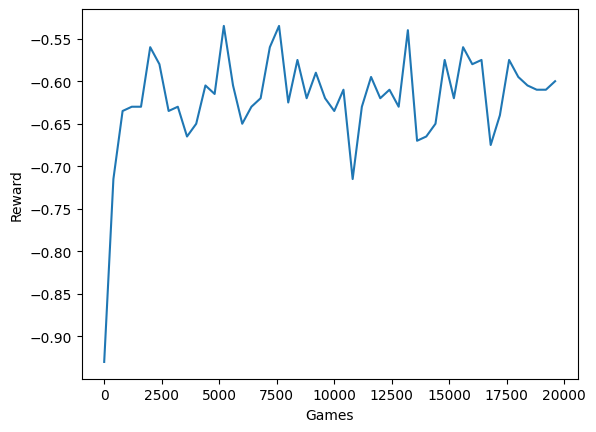

In [119]:
# Calculate and print the average reward per thousand episodes
n = int(num_episodes/50)
rewards_per_thousand_episodes = list(map(lambda x: sum(x)/n, np.split(np.array(rewards_all_episodes), num_episodes/n)))
ind = np.arange(len(rewards_per_thousand_episodes))*n
plt.xlabel("Games")
plt.ylabel("Reward")
plt.plot(ind, rewards_per_thousand_episodes)